In [ ]:
# Análisis de Datos de Videojuegos - Proyecto Ice
## Identificación de patrones para determinar el éxito de videojuegos
  
**Objetivo:** Analizar datos históricos de videojuegos para identificar patrones de éxito

In [ ]:
## Introducción

Este proyecto analiza datos de ventas de videojuegos para la tienda online Ice. 
El objetivo es identificar patrones que determinen si un juego tiene éxito, 
permitiendo detectar proyectos prometedores y planificar campañas publicitarias.

### Dataset
- **Fuente:** Datos históricos hasta 2016
- **Contenido:** Reseñas de usuarios, géneros, plataformas, ventas por región
- **Objetivo:** Planificar campaña para 2017

In [ ]:
## Paso 1: Carga y Exploración Inicial de Datos

En esta sección cargaremos el dataset y realizaremos una exploración inicial 
para entender la estructura y calidad de los datos.

In [1]:
import pandas as pd

In [2]:
ice = pd.read_csv('/datasets/games.csv')

In [3]:
print(ice.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB
None


In [4]:
print(ice.head(10))

                        Name Platform  Year_of_Release         Genre  \
0                 Wii Sports      Wii           2006.0        Sports   
1          Super Mario Bros.      NES           1985.0      Platform   
2             Mario Kart Wii      Wii           2008.0        Racing   
3          Wii Sports Resort      Wii           2009.0        Sports   
4   Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing   
5                     Tetris       GB           1989.0        Puzzle   
6      New Super Mario Bros.       DS           2006.0      Platform   
7                   Wii Play      Wii           2006.0          Misc   
8  New Super Mario Bros. Wii      Wii           2009.0      Platform   
9                  Duck Hunt      NES           1984.0       Shooter   

   NA_sales  EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     41.36     28.96      3.77         8.45          76.0          8      E  
1     29.08      3.58      6.81         0.77     

In [5]:
columns_new = {
    'Name' : 'name',
    'Platform' : 'platform',
    'Year_of_Release' : 'year_of_release',
    'Genre' : 'genre',
    'NA_sales' : 'na_sales',
    'EU_sales' : 'eu_sales', 
    'JP_sales' : 'jp_sales',
    'Other_sales' : 'other_sales',
    'Critic_Score' : 'critic_score',
    'User_Score' : 'user_score',
    'Rating' : 'rating'
}

ice.rename(columns=columns_new, inplace=True)

print(ice.columns)


Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [ ]:
### Objetivos:
1. Preparar los datos
2. Realizar análisis exploratorio
3. Probar hipótesis estadísticas

In [6]:

# Convierte a int, manteniendo los NaN como NaN
ice['year_of_release'] = ice['year_of_release'].astype('Int64')

print(ice.head(10))

                        name platform  year_of_release         genre  \
0                 Wii Sports      Wii             2006        Sports   
1          Super Mario Bros.      NES             1985      Platform   
2             Mario Kart Wii      Wii             2008        Racing   
3          Wii Sports Resort      Wii             2009        Sports   
4   Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
5                     Tetris       GB             1989        Puzzle   
6      New Super Mario Bros.       DS             2006      Platform   
7                   Wii Play      Wii             2006          Misc   
8  New Super Mario Bros. Wii      Wii             2009      Platform   
9                  Duck Hunt      NES             1984       Shooter   

   na_sales  eu_sales  jp_sales  other_sales  critic_score user_score rating  
0     41.36     28.96      3.77         8.45          76.0          8      E  
1     29.08      3.58      6.81         0.77     

In [ ]:
se cambio a tipo de datos int la columna de year_of_release ya que dicha columna se basa en el año de lanzamiento del juego y como bien sabemos,
no hay años que existan con decimales

In [7]:
# valores ausentes 

ice.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [8]:
# Sustituir valores ausentes en las columnas, year_of_release, critic_score, user_score, rating.

columnas_a_remplazar = ['year_of_release', 'critic_score', 'user_score', 'rating']

for columnas in columnas_a_remplazar:
    ice[columnas].fillna(0, inplace=True)

print(ice.isna().sum())


name               2
platform           0
year_of_release    0
genre              2
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64


In [9]:
# Valores duplicados 

ice.duplicated().sum()

0

In [ ]:
los valores ausentes decidi pasarlos a 0 por que para el periodo en donde se estan sustrayendo, probablemente aun no
se evaluavan las columnas de critic_score, user_score, rating ya que para el cliente no eran necesarias, sin embargo, 
al pasar el tiempo se decidio que estos datos eran importantes para evaluar las ventas y la experiencia con el cliente.

In [10]:
ice.sample(n=10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
3367,New Play Control! Donkey Kong Jungle Beat,Wii,2008,Platform,0.23,0.17,0.14,0.05,0.0,0,0
6663,Samurai Shodown II,NG,1994,Fighting,0.00,0.00,0.25,0.00,0.0,0,0
16583,Taishou x Alice: All in One,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,0,0
11821,Hero Bank,3DS,2014,Role-Playing,0.00,0.00,0.07,0.00,0.0,0,0
8047,X-Men Origins: Wolverine,PS2,2009,Action,0.13,0.00,0.00,0.05,0.0,6.8,T
9470,Drakengard 2,PS2,2005,Role-Playing,0.06,0.05,0.00,0.02,58.0,5.5,M
2210,EA Sports UFC 2,PS4,2016,Sports,0.29,0.49,0.00,0.15,79.0,6.2,T
6214,The Smurfs: Dance Party,Wii,2011,Misc,0.21,0.04,0.00,0.02,0.0,tbd,E
3631,The Activision Decathlon,2600,1982,Sports,0.52,0.03,0.00,0.01,0.0,0,0
6664,My Virtual Tutor: Reading Adventure Kindergart...,DS,2009,Misc,0.23,0.00,0.00,0.02,0.0,0,0


In [ ]:
para los casos en la columna de user_score que tienen como valor tbd, se evaluara de nuevo con el cliente para que en futuras ocaciones, los ususarios evaluen el juego antes de abandonarlo


In [11]:
# Ventas totales por juego

columnas_ventas = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
ice['total_sales'] = ice[columnas_ventas].sum(axis=1)

print(ice[['name', 'total_sales']].head(10))

# Ver los juegos con mayores ventas totales
print("Top 5 juegos con mayores ventas:")
print(ice.nlargest(5, 'total_sales')[['name', 'platform', 'total_sales']])

# Estadísticas básicas de ventas totales
print("\nEstadísticas de ventas totales:")
print(ice['total_sales'].describe())


                        name  total_sales
0                 Wii Sports        82.54
1          Super Mario Bros.        40.24
2             Mario Kart Wii        35.52
3          Wii Sports Resort        32.77
4   Pokemon Red/Pokemon Blue        31.38
5                     Tetris        30.26
6      New Super Mario Bros.        29.80
7                   Wii Play        28.91
8  New Super Mario Bros. Wii        28.32
9                  Duck Hunt        28.31
Top 5 juegos con mayores ventas:
                       name platform  total_sales
0                Wii Sports      Wii        82.54
1         Super Mario Bros.      NES        40.24
2            Mario Kart Wii      Wii        35.52
3         Wii Sports Resort      Wii        32.77
4  Pokemon Red/Pokemon Blue       GB        31.38

Estadísticas de ventas totales:
count    16715.000000
mean         0.533396
std          1.548261
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540

In [12]:
# Juegos lanzados por año

juegos_por_año = ice['year_of_release'].value_counts().sort_index()
print("Juegos lanzados por año:")
print(juegos_por_año)


Juegos lanzados por año:
0        269
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64


In [13]:
# Ventas totales por plataforma
ventas_por_plataforma = ice.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Ventas totales por plataforma:")
print(ventas_por_plataforma.head(10))


Ventas totales por plataforma:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


In [14]:
# Seleccionar las top 10 plataformas con mayores ventas
top_plataformas = ventas_por_plataforma.head(10).index.tolist()
print(f"\nTop 10 plataformas: {top_plataformas}")

# Filtrar datos solo para estas plataformas
ice_top = ice[ice['platform'].isin(top_plataformas)]


Top 10 plataformas: ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA', 'PS4', 'PSP', 'PC']


In [15]:
# Crear tabla de ventas por plataforma y año
ventas_plataforma_año = ice_top.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)
print("\nVentas por plataforma y año (primeras 10 filas):")
print(ventas_plataforma_año.tail(10))


Ventas por plataforma y año (primeras 10 filas):
platform             DS  GBA     PC   PS    PS2     PS3     PS4    PSP  \
year_of_release                                                          
2007             146.94  3.4   9.28  0.0  75.99   73.19    0.00  46.93   
2008             145.31  0.0  12.42  0.0  53.90  118.52    0.00  34.55   
2009             119.54  0.0  16.91  0.0  26.40  130.93    0.00  37.78   
2010              85.02  0.0  24.28  0.0   5.64  142.17    0.00  35.04   
2011              26.18  0.0  35.03  0.0   0.45  156.78    0.00  17.82   
2012              11.01  0.0  23.22  0.0   0.00  107.36    0.00   7.69   
2013               1.54  0.0  12.38  0.0   0.00  113.25   25.99   3.14   
2014               0.00  0.0  13.28  0.0   0.00   47.76  100.00   0.24   
2015               0.00  0.0   8.52  0.0   0.00   16.82  118.90   0.12   
2016               0.00  0.0   5.25  0.0   0.00    3.60   69.25   0.00   

platform            Wii    X360  
year_of_release            

In [ ]:
### Características del dataset:
- Ventas por región
- Calificaciones de usuarios
- Géneros de videojuegos

In [16]:
# Analizar el último año con ventas significativas para cada plataforma
ultimo_año_ventas = {}
for plataforma in top_plataformas:
    datos_plataforma = ice_top[ice_top['platform'] == plataforma]
    años_con_ventas = datos_plataforma[datos_plataforma['total_sales'] > 0.1]['year_of_release']
    if len(años_con_ventas) > 0:
        ultimo_año_ventas[plataforma] = años_con_ventas.max()

print("\nÚltimo año con ventas significativas por plataforma:")
for plataforma, año in sorted(ultimo_año_ventas.items(), key=lambda x: x[1]):
    print(f"{plataforma}: {año}")


Último año con ventas significativas por plataforma:
PS: 2003
GBA: 2007
PS2: 2011
DS: 2013
PSP: 2013
X360: 2016
PS3: 2016
Wii: 2016
PS4: 2016
PC: 2016


In [17]:
# Calcular primer y último año de cada plataforma
ciclo_vida = ice.groupby('platform')['year_of_release'].agg(['min', 'max'])
ciclo_vida['duracion'] = ciclo_vida['max'] - ciclo_vida['min']
ciclo_vida = ciclo_vida.sort_values('duracion', ascending=False)

print("\nCiclo de vida de plataformas (duración en años):")
print(ciclo_vida.head(15))


Ciclo de vida de plataformas (duración en años):
          min   max  duracion
platform                     
3DS         0  2016      2016
X360        0  2016      2016
Wii         0  2016      2016
PSV         0  2016      2016
PC          0  2016      2016
PS3         0  2016      2016
PSP         0  2015      2015
DS          0  2013      2013
PS2         0  2011      2011
XB          0  2008      2008
GBA         0  2007      2007
GC          0  2007      2007
PS          0  2003      2003
N64         0  2002      2002
GB          0  2001      2001


In [ ]:
# para construir un modelo para 2017, se consideraran los datos apartir del 2008 ya que hubo un boom de la industria y 
# mayor diversidad de productos, tambien mayor volumen de ventas por popularidad creciente, 
# aunado a la transición tecnologica hacia plataformas modernas. 

In [18]:
ice_modelo_2017 = ice[(ice['year_of_release'] >=2008) & (ice['year_of_release'] <=2016)]

print(ice_modelo_2017.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8130 entries, 2 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             8130 non-null   object 
 1   platform         8130 non-null   object 
 2   year_of_release  8130 non-null   Int64  
 3   genre            8130 non-null   object 
 4   na_sales         8130 non-null   float64
 5   eu_sales         8130 non-null   float64
 6   jp_sales         8130 non-null   float64
 7   other_sales      8130 non-null   float64
 8   critic_score     8130 non-null   float64
 9   user_score       8130 non-null   object 
 10  rating           8130 non-null   object 
 11  total_sales      8130 non-null   float64
dtypes: Int64(1), float64(6), object(5)
memory usage: 833.6+ KB
None


In [19]:
ice_modelo_2017.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77
8,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,28.32
14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,61.0,6.3,E,21.82
15,Wii Fit Plus,Wii,2009,Sports,9.01,8.49,2.53,1.77,80.0,7.4,E,21.80
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
27,Pokemon Black/Pokemon White,DS,2010,Role-Playing,5.51,3.17,5.65,0.80,0.0,0,0,15.13
29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,0.0,0,0,14.63


In [20]:
# Ventas totales por plataforma en el período 2008-2016
ventas_por_plataforma_2017 = ice_modelo_2017.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("Plataformas líderes en ventas (2008-2016):")
print(ventas_por_plataforma_2017.head(10))

Plataformas líderes en ventas (2008-2016):
platform
PS3     837.19
X360    805.96
Wii     601.26
DS      388.60
PS4     314.14
3DS     257.81
XOne    159.32
PC      151.29
PSP     136.38
PS2      86.39
Name: total_sales, dtype: float64


In [21]:
# Ventas por plataforma y año
ventas_plataforma_año_2017 = ice_modelo_2017.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)
print("\nVentas por plataforma y año:")
print(ventas_plataforma_año_2017)


Ventas por plataforma y año:
platform           3DS    DC      DS     PC    PS2     PS3     PS4    PSP  \
year_of_release                                                             
2008              0.00  0.04  145.31  12.42  53.90  118.52    0.00  34.55   
2009              0.00  0.00  119.54  16.91  26.40  130.93    0.00  37.78   
2010              0.00  0.00   85.02  24.28   5.64  142.17    0.00  35.04   
2011             63.20  0.00   26.18  35.03   0.45  156.78    0.00  17.82   
2012             51.36  0.00   11.01  23.22   0.00  107.36    0.00   7.69   
2013             56.57  0.00    1.54  12.38   0.00  113.25   25.99   3.14   
2014             43.76  0.00    0.00  13.28   0.00   47.76  100.00   0.24   
2015             27.78  0.00    0.00   8.52   0.00   16.82  118.90   0.12   
2016             15.14  0.00    0.00   5.25   0.00    3.60   69.25   0.00   

platform           PSV     Wii   WiiU    X360    XB   XOne  
year_of_release                                             


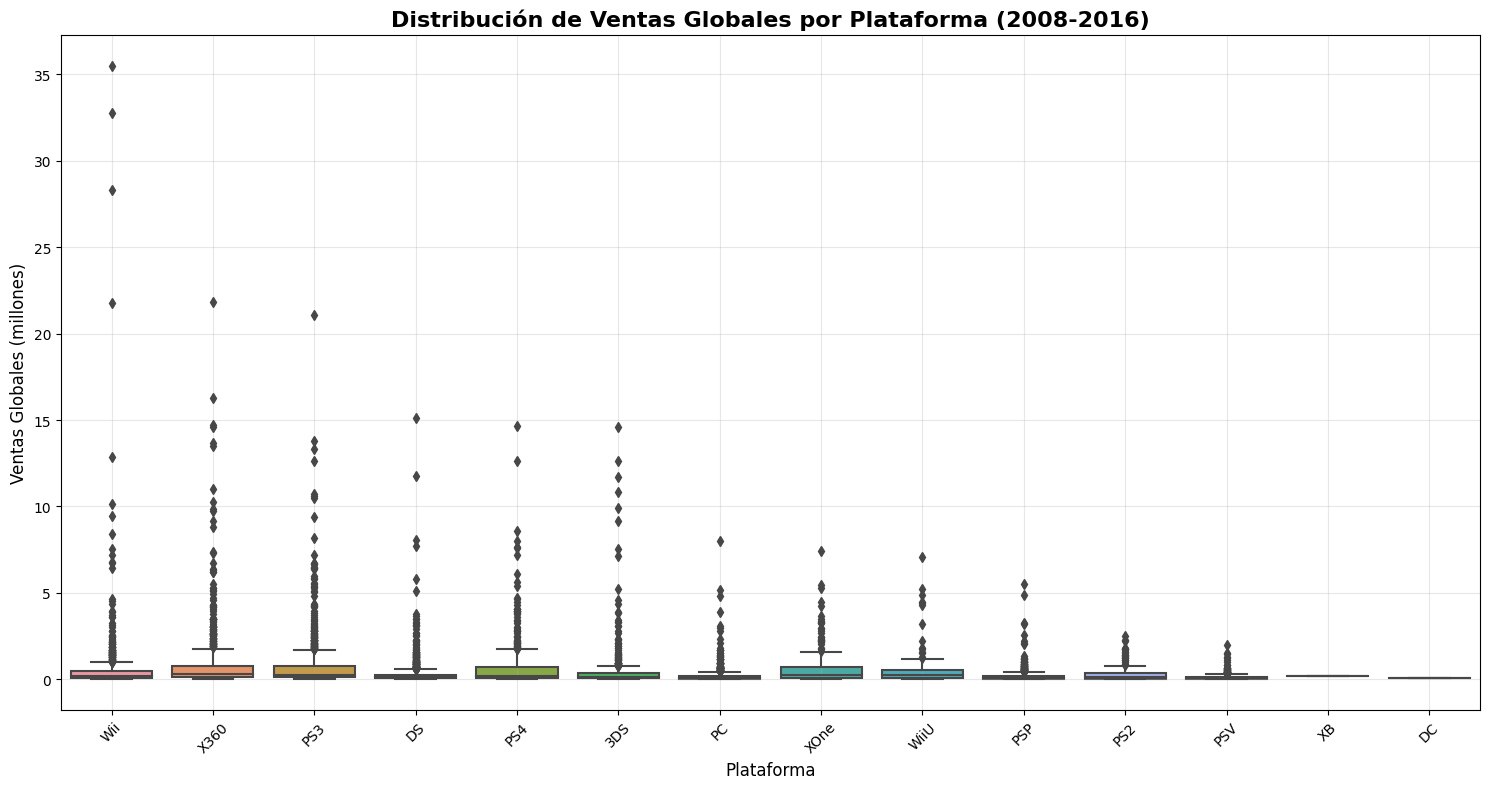

In [22]:
# Diagrama de caja para ventas globales de todos los juegos

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))

sns.boxplot(data=ice_modelo_2017, x='platform', y='total_sales')

plt.title('Distribución de Ventas Globales por Plataforma (2008-2016)', fontsize=16, fontweight='bold')
plt.xlabel('Plataforma', fontsize=12)
plt.ylabel('Ventas Globales (millones)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
# Si son significativas las diferencias en ventas como lo muestran los diagramas de caja anteriores, siendo Wii el mayor producto vendido 
# a nivel global y a nivel producción. 

In [23]:
# Ventas promedio por plataforma 

ventas_promedio_plataforma = ice_modelo_2017.groupby('platform')['total_sales'].mean()

# Mostrar los resultados ordenados de mayor a menor
print("Ventas promedio por plataforma (en millones):")
print(ventas_promedio_plataforma.sort_values(ascending=False))


Ventas promedio por plataforma (en millones):
platform
X360    0.807575
PS4     0.801378
PS3     0.704113
XOne    0.645020
Wii     0.568836
WiiU    0.559116
3DS     0.503535
DS      0.277175
PS2     0.260211
PC      0.228535
XB      0.180000
PSP     0.179212
PSV     0.125431
DC      0.040000
Name: total_sales, dtype: float64


In [24]:
# Estadísticas completas por plataforma
estadisticas_completas = ice_modelo_2017.groupby('platform')['total_sales'].agg([
    'mean',    # Media (promedio)
    'median',  # Mediana
    'count',   # Número de juegos
    'std'      # Desviación estándar
]).round(2)

# Ordenar por promedio de mayor a menor
estadisticas_completas = estadisticas_completas.sort_values('mean', ascending=False)
print("\nEstadísticas completas por plataforma:")
print(estadisticas_completas)


Estadísticas completas por plataforma:
          mean  median  count   std
platform                           
X360      0.81    0.28    998  1.70
PS4       0.80    0.20    392  1.61
PS3       0.70    0.26   1189  1.43
XOne      0.65    0.22    247  1.04
Wii       0.57    0.19   1057  2.05
WiiU      0.56    0.22    147  1.06
3DS       0.50    0.12    512  1.44
DS        0.28    0.10   1402  0.74
PS2       0.26    0.14    332  0.37
PC        0.23    0.05    662  0.56
PSP       0.18    0.07    761  0.39
XB        0.18    0.18      1   NaN
PSV       0.13    0.05    429  0.21
DC        0.04    0.04      1   NaN


In [ ]:
# Para las ventas promedio, X360 es el producto más vendido y consumido por los clientes, siendo el preferido por el publico
# consumidor

In [25]:
# Gráfico de dispersión para analizar la correlación entre las reseñas de usuarios y las ventas de X360.

x360_data = ice_modelo_2017[ice_modelo_2017['platform'] == 'X360'].copy()
print(f"Número de juegos de X360: {len(x360_data)}")

Número de juegos de X360: 998


In [26]:
# Verificar qué valores únicos tiene user_score en X360
print("Valores únicos en user_score para X360:")
print(x360_data['user_score'].value_counts().head(10))

# Convertir user_score a numérico, excluyendo valores como 'tbd' y '0'
x360_data_clean = x360_data[
    (x360_data['user_score'] != '0') & 
    (x360_data['user_score'] != 'tbd')
].copy()

# Convertir a float
x360_data_clean['user_score_numeric'] = pd.to_numeric(x360_data_clean['user_score'], errors='coerce')

# Eliminar valores NaN después de la conversión
x360_data_clean = x360_data_clean.dropna(subset=['user_score_numeric'])
print(f"Juegos de X360 con datos válidos: {len(x360_data_clean)}")

Valores únicos en user_score para X360:
0      176
tbd     74
7       33
7.2     30
7.5     29
7.8     29
7.6     26
8       23
7.9     23
8.2     21
Name: user_score, dtype: int64
Juegos de X360 con datos válidos: 924


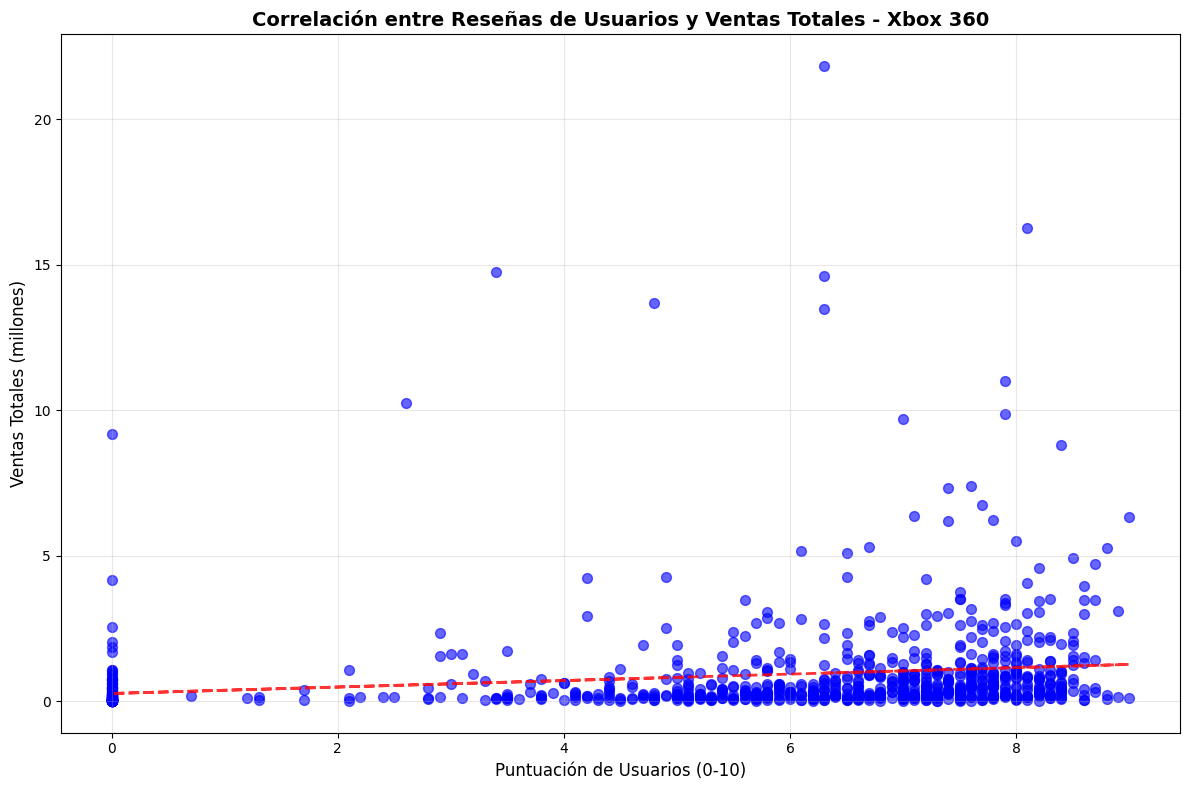

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Crear el gráfico de dispersión
plt.figure(figsize=(12, 8))
plt.scatter(x360_data_clean['user_score_numeric'], x360_data_clean['total_sales'], 
           alpha=0.6, s=50, color='blue')

plt.title('Correlación entre Reseñas de Usuarios y Ventas Totales - Xbox 360', 
          fontsize=14, fontweight='bold')
plt.xlabel('Puntuación de Usuarios (0-10)', fontsize=12)
plt.ylabel('Ventas Totales (millones)', fontsize=12)
plt.grid(True, alpha=0.3)

# Agregar línea de tendencia
z = np.polyfit(x360_data_clean['user_score_numeric'], x360_data_clean['total_sales'], 1)
p = np.poly1d(z)
plt.plot(x360_data_clean['user_score_numeric'], p(x360_data_clean['user_score_numeric']), 
         "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()

In [ ]:
# los usuarios han dado una puntuacion de entre 6 y 8 al juego Xbox 360. la mayor parte del mercado a aceptado de buena manera 
# el juego

In [28]:
# Encontrar juegos que aparecen en múltiples plataformas
juegos_multiplataforma = ice_modelo_2017.groupby('name')['platform'].nunique()
juegos_con_multiples_plataformas = juegos_multiplataforma[juegos_multiplataforma > 1].sort_values(ascending=False)

print("Juegos con más plataformas:")
print(juegos_con_multiples_plataformas.head(10))
print(f"\nTotal de juegos en múltiples plataformas: {len(juegos_con_multiples_plataformas)}")

Juegos con más plataformas:
name
FIFA 14                         9
LEGO Marvel Super Heroes        9
LEGO Jurassic World             8
Lego Batman 3: Beyond Gotham    8
Angry Birds Star Wars           8
Terraria                        8
FIFA Soccer 13                  8
LEGO The Hobbit                 8
The LEGO Movie Videogame        8
FIFA 15                         8
Name: platform, dtype: int64

Total de juegos en múltiples plataformas: 1482


In [32]:
# Obtener los nombres de los juegos más populares en múltiples plataformas
top_juegos_multiplataforma = juegos_con_multiples_plataformas.head(10).index.tolist()

# Crear un DataFrame con estos juegos
comparacion_juegos = ice_modelo_2017[ice_modelo_2017['name'].isin(top_juegos_multiplataforma)]

# Ver las plataformas de cada juego
print("Plataformas por juego:")
for juego in top_juegos_multiplataforma[:5]:  
    plataformas = comparacion_juegos[comparacion_juegos['name'] == juego]['platform'].unique()
    print(f"{juego}: {list(plataformas)}")

Plataformas por juego:
FIFA 14: ['PS3', 'X360', 'PS4', 'XOne', 'PSV', 'PC', 'Wii', '3DS', 'PSP']
LEGO Marvel Super Heroes: ['X360', 'PS3', 'PS4', 'XOne', '3DS', 'WiiU', 'PSV', 'DS', 'PC']
LEGO Jurassic World: ['PS4', 'X360', 'PS3', 'XOne', '3DS', 'WiiU', 'PSV', 'PC']
Lego Batman 3: Beyond Gotham: ['PS4', 'X360', 'PS3', '3DS', 'WiiU', 'XOne', 'PSV', 'PC']
Angry Birds Star Wars: ['3DS', 'PS3', 'X360', 'Wii', 'PS4', 'XOne', 'WiiU', 'PSV']


In [30]:
# Crear tabla pivote para comparar ventas por juego y plataforma
tabla_comparativa = comparacion_juegos.pivot_table(
    index='name', 
    columns='platform', 
    values='total_sales', 
    fill_value=0
).round(2)

print("Ventas por juego y plataforma (en millones):")
print(tabla_comparativa.head(10))

Ventas por juego y plataforma (en millones):
platform                       3DS    DS    PC   PS3   PS4   PSP   PSV   Wii  \
name                                                                           
Angry Birds Star Wars         0.33  0.00  0.00  0.29  0.22  0.00  0.08  0.26   
FIFA 14                       0.23  0.00  0.40  6.46  3.01  0.19  0.41  0.38   
FIFA 15                       0.46  0.00  0.29  4.28  6.08  0.00  0.60  0.56   
FIFA Soccer 13                0.29  0.00  0.40  8.17  0.00  0.34  0.44  0.69   
LEGO Jurassic World           0.62  0.00  0.04  0.85  0.90  0.00  0.23  0.00   
LEGO Marvel Super Heroes      0.89  0.38  0.17  1.83  1.62  0.00  0.51  0.00   
LEGO The Hobbit               0.24  0.00  0.05  0.46  0.60  0.00  0.14  0.00   
Lego Batman 3: Beyond Gotham  0.45  0.00  0.06  0.73  0.92  0.00  0.31  0.00   
Terraria                      0.09  0.00  0.14  0.41  0.07  0.00  0.10  0.00   
The LEGO Movie Videogame      0.69  0.00  0.06  0.93  0.67  0.00  0.30  0.0

In [31]:
# Analizar un juego específico (por ejemplo, el que tenga más plataformas)
juego_ejemplo = juegos_con_multiples_plataformas.index[0]
print(f"\nAnálisis detallado de: {juego_ejemplo}")

datos_juego = ice_modelo_2017[ice_modelo_2017['name'] == juego_ejemplo]
analisis_juego = datos_juego[['platform', 'total_sales', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sort_values('total_sales', ascending=False)

print(analisis_juego)


Análisis detallado de: FIFA 14
     platform  total_sales  na_sales  eu_sales  jp_sales  other_sales
126       PS3         6.46      0.78      4.24      0.07         1.37
271      X360         4.22      0.92      2.89      0.01         0.40
469       PS4         3.01      0.61      1.85      0.11         0.44
1753     XOne         1.16      0.41      0.66      0.00         0.09
4699      PSV         0.41      0.08      0.23      0.01         0.09
4809       PC         0.40      0.01      0.36      0.00         0.03
4985      Wii         0.38      0.00      0.36      0.00         0.02
6871      3DS         0.23      0.00      0.22      0.00         0.01
7875      PSP         0.19      0.00      0.15      0.00         0.04


In [ ]:
# Estados Unidos es el mayor consumidor de juegos 

In [33]:
# Top 5 plataformas por ventas totales en el período 2008-2016
top_5_plataformas = ice_modelo_2017.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 plataformas por ventas totales:")
print(top_5_plataformas)

plataformas_principales = top_5_plataformas.index.tolist()
print(f"\nPlataformas principales: {plataformas_principales}")

Top 5 plataformas por ventas totales:
platform
PS3     837.19
X360    805.96
Wii     601.26
DS      388.60
PS4     314.14
Name: total_sales, dtype: float64

Plataformas principales: ['PS3', 'X360', 'Wii', 'DS', 'PS4']


In [34]:
# Top 5 géneros por ventas totales
top_5_generos = ice_modelo_2017.groupby('genre')['total_sales'].sum().sort_values(ascending=False).head(5)
print("\nTop 5 géneros por ventas totales:")
print(top_5_generos)

generos_principales = top_5_generos.index.tolist()
print(f"\nGéneros principales: {generos_principales}")


Top 5 géneros por ventas totales:
genre
Action          945.74
Shooter         608.19
Sports          560.34
Role-Playing    421.57
Misc            396.43
Name: total_sales, dtype: float64

Géneros principales: ['Action', 'Shooter', 'Sports', 'Role-Playing', 'Misc']


In [35]:
# Clasificaciones ESRB más comunes (excluyendo '0')
clasificaciones_esrb = ice_modelo_2017[ice_modelo_2017['rating'] != '0']['rating'].value_counts()
print("\nClasificaciones ESRB más comunes:")
print(clasificaciones_esrb)


Clasificaciones ESRB más comunes:
0       3025
E       1823
T       1362
E10+     980
M        933
EC         6
RP         1
Name: rating, dtype: int64


In [36]:
# Análisis de preferencias de plataformas por región
print("=== PERFIL DE PLATAFORMAS POR REGIÓN ===\n")

regiones = ['na_sales', 'eu_sales', 'jp_sales']
nombres_regiones = ['Norteamérica (NA)', 'Europa (EU)', 'Japón (JP)']

for i, (region, nombre_region) in enumerate(zip(regiones, nombres_regiones)):
    print(f"--- {nombre_region} ---")
    
    # Filtrar solo las top 5 plataformas
    datos_region = ice_modelo_2017[ice_modelo_2017['platform'].isin(plataformas_principales)]
    
    # Ventas por plataforma en esta región
    ventas_plataforma_region = datos_region.groupby('platform')[region].sum().sort_values(ascending=False)
    
    print("Ventas por plataforma (millones):")
    print(ventas_plataforma_region)
    
    # Porcentaje de participación
    total_ventas_region = ventas_plataforma_region.sum()
    porcentajes = (ventas_plataforma_region / total_ventas_region * 100).round(1)
    print("\nParticipación de mercado (%):")
    print(porcentajes)
    print("\n" + "="*50 + "\n")

=== PERFIL DE PLATAFORMAS POR REGIÓN ===

--- Norteamérica (NA) ---
Ventas por plataforma (millones):
platform
X360    490.69
PS3     349.13
Wii     332.87
DS      198.73
PS4     108.74
Name: na_sales, dtype: float64

Participación de mercado (%):
platform
X360    33.2
PS3     23.6
Wii     22.5
DS      13.4
PS4      7.3
Name: na_sales, dtype: float64


--- Europa (EU) ---
Ventas por plataforma (millones):
platform
PS3     293.73
X360    234.88
Wii     170.74
PS4     141.09
DS       86.13
Name: eu_sales, dtype: float64

Participación de mercado (%):
platform
PS3     31.7
X360    25.3
Wii     18.4
PS4     15.2
DS       9.3
Name: eu_sales, dtype: float64


--- Japón (JP) ---
Ventas por plataforma (millones):
platform
DS      76.12
PS3     74.11
Wii     47.01
PS4     15.96
X360     9.30
Name: jp_sales, dtype: float64

Participación de mercado (%):
platform
DS      34.2
PS3     33.3
Wii     21.1
PS4      7.2
X360     4.2
Name: jp_sales, dtype: float64




In [37]:
# Importar las librerías necesarias para las pruebas de hipótesis
from scipy import stats
import numpy as np
import pandas as pd

# Establecer el valor alfa
alpha = 0.05
print(f"Valor alfa establecido: {alpha}")
print("="*60)

Valor alfa establecido: 0.05


In [38]:
# HIPÓTESIS 1: Calificaciones promedio de usuarios Xbox One vs PC
print("HIPÓTESIS 1: Xbox One vs PC")
print("H₀: μ_Xbox_One = μ_PC (las calificaciones promedio son iguales)")
print("H₁: μ_Xbox_One ≠ μ_PC (las calificaciones promedio son diferentes)")
print(f"α = {alpha}")
print("-" * 50)

# Filtrar datos para Xbox One y PC con calificaciones válidas
xbox_data = ice_modelo_2017[
    (ice_modelo_2017['platform'] == 'XOne') & 
    (ice_modelo_2017['user_score'] != '0') & 
    (ice_modelo_2017['user_score'] != 'tbd')
].copy()

pc_data = ice_modelo_2017[
    (ice_modelo_2017['platform'] == 'PC') & 
    (ice_modelo_2017['user_score'] != '0') & 
    (ice_modelo_2017['user_score'] != 'tbd')
].copy()

# Convertir user_score a numérico
xbox_data['user_score_numeric'] = pd.to_numeric(xbox_data['user_score'], errors='coerce')
pc_data['user_score_numeric'] = pd.to_numeric(pc_data['user_score'], errors='coerce')

# Eliminar valores NaN
xbox_scores = xbox_data['user_score_numeric'].dropna()
pc_scores = pc_data['user_score_numeric'].dropna()

print(f"Muestra Xbox One: {len(xbox_scores)} juegos")
print(f"Muestra PC: {len(pc_scores)} juegos")
print(f"Promedio Xbox One: {xbox_scores.mean():.2f}")
print(f"Promedio PC: {pc_scores.mean():.2f}")

HIPÓTESIS 1: Xbox One vs PC
H₀: μ_Xbox_One = μ_PC (las calificaciones promedio son iguales)
H₁: μ_Xbox_One ≠ μ_PC (las calificaciones promedio son diferentes)
α = 0.05
--------------------------------------------------
Muestra Xbox One: 236 juegos
Muestra PC: 620 juegos
Promedio Xbox One: 5.03
Promedio PC: 5.58


In [39]:
# Realizar prueba t de Student para muestras independientes
t_stat_1, p_value_1 = stats.ttest_ind(xbox_scores, pc_scores)

print(f"\nResultados de la prueba t:")
print(f"Estadístico t: {t_stat_1:.4f}")
print(f"Valor p: {p_value_1:.4f}")

# Interpretar resultados
if p_value_1 < alpha:
    print(f"Conclusión: Rechazamos H₀ (p < {alpha})")
    print("Existe diferencia estadísticamente significativa entre las calificaciones")
else:
    print(f"Conclusión: No rechazamos H₀ (p ≥ {alpha})")
    print("No hay evidencia suficiente de diferencia significativa")

print("="*60)


Resultados de la prueba t:
Estadístico t: -2.4679
Valor p: 0.0138
Conclusión: Rechazamos H₀ (p < 0.05)
Existe diferencia estadísticamente significativa entre las calificaciones


In [ ]:
###  la hipotesis nula y alternativa fue basandome en las calificaiones promedio para saber si eran iguales o diferentes 